# 🧠 Self-Attention from Scratch — Starting from a Real Sentence

> **Goal:** Walk through self-attention end-to-end, starting from raw words — not hand-crafted vectors.

---

## 🎬 The Story We'll Use

**Sentence:** `"The cat sat on the mat"`

This is a classic NLP sentence. Let's see how self-attention helps each word understand its context.

---

## 🗺️ Our Journey

```
Sentence → Tokenize → Word Embeddings → Q, K, V → Attention Scores → Softmax → Output
```

Each step builds on the previous. By the end, every word will have a **context-aware** representation.

## 🟢 Step 1 — Tokenize the Sentence

The first thing any NLP model does is split the sentence into **tokens** (words, in our case).

Each token will get its own vector representation in the next step.

In [1]:
import numpy as np

# --- INPUT: Change this sentence to try different examples! ---
sentence = "The cat sat on the mat"

# Tokenize: split into words, lowercase
tokens = sentence.lower().split()

print(f"Input sentence : '{sentence}'")
print(f"Tokens         : {tokens}")
print(f"Number of tokens: {len(tokens)}")

Input sentence : 'The cat sat on the mat'
Tokens         : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Number of tokens: 6


## 🟢 Step 2 — Learnable Word Embeddings

In a real transformer, each word in the vocabulary gets an index, and there's a single **embedding matrix** `E` of shape `(vocab_size, embed_dim)`. Looking up a word's embedding = selecting a row from `E`.

These embeddings **start random** and are updated during training via backpropagation — the model learns which directions in vector space are meaningful.

Here we simulate exactly that:
1. Build a vocabulary from the sentence
2. Assign each word an integer index
3. Initialize `E` randomly (this is what gets *trained* in a real model)
4. Look up each token's embedding by its index

> **No values are hand-crafted.** The embedding matrix is randomly initialized — just like at the start of training.

In [3]:
np.random.seed(0)   # for reproducibility — remove this to see different random inits

embed_dim = 4

# Build vocabulary from the sentence (unique words, sorted for consistency)
vocab      = sorted(set(tokens))
word2idx   = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)

# Learnable embedding matrix: shape (vocab_size, embed_dim)
# In training, gradients flow back into E and update these values
E = np.random.randn(vocab_size, embed_dim) * 0.5

# Look up each token's embedding by index
token_ids = [word2idx[t] for t in tokens]
X = E[token_ids]   # shape: (n_tokens, embed_dim)

print(f"Vocabulary  : {vocab}")
print(f"Word → Index: {word2idx}")
print(f"Token IDs   : {token_ids}")
print()
print(f"Embedding matrix E  shape: {E.shape}  (vocab_size × embed_dim)")
print(f"Input matrix X      shape: {X.shape}  (n_tokens × embed_dim)")
print()
print("Token → Embedding (randomly initialized, would be learned during training)")
print("-" * 60)
for i, token in enumerate(tokens):
    print(f"  {token:6s} [idx={token_ids[i]}]  →  {X[i].round(3)}")

Vocabulary  : ['cat', 'mat', 'on', 'sat', 'the']
Word → Index: {'cat': 0, 'mat': 1, 'on': 2, 'sat': 3, 'the': 4}
Token IDs   : [4, 0, 3, 2, 4, 1]

Embedding matrix E  shape: (5, 4)  (vocab_size × embed_dim)
Input matrix X      shape: (6, 4)  (n_tokens × embed_dim)

Token → Embedding (randomly initialized, would be learned during training)
------------------------------------------------------------
  the    [idx=4]  →  [ 0.747 -0.103  0.157 -0.427]
  cat    [idx=0]  →  [0.882 0.2   0.489 1.12 ]
  sat    [idx=3]  →  [0.381 0.061 0.222 0.167]
  on     [idx=2]  →  [-0.052  0.205  0.072  0.727]
  the    [idx=4]  →  [ 0.747 -0.103  0.157 -0.427]
  mat    [idx=1]  →  [ 0.934 -0.489  0.475 -0.076]


## 🟢 Step 3 — Project into Q¨(Query), K(Key), V(Value) Spaces

Self-attention doesn't use the raw embeddings directly.
It projects them into three separate spaces using learned weight matrices:

```
Q = X @ Wq   ← "What am I looking for?"
K = X @ Wk   ← "What do I offer to others?"
V = X @ Wv   ← "What content do I share when selected?"
```

**Why three separate projections?**
Because a word's *search intent* (Q), *identity* (K), and *content* (V) can be different things.
A verb like "sat" might advertise itself as an action (K), but when selected, share information about *who* did it (V).

Wq, Wk, Wv are initialized randomly (same seed as Step 2) — they would be learned during training.

In [4]:
proj_dim = 3   # project down to 3D for Q, K, V

# Learnable weight matrices (random here; trained in real transformers)
Wq = np.random.randn(embed_dim, proj_dim) * 0.5
Wk = np.random.randn(embed_dim, proj_dim) * 0.5
Wv = np.random.randn(embed_dim, proj_dim) * 0.5

Q = X @ Wq   # shape: (n_tokens, proj_dim)
K = X @ Wk
V = X @ Wv

print(f"Q shape: {Q.shape}  — one query vector per token")
print(f"K shape: {K.shape}  — one key   vector per token")
print(f"V shape: {V.shape}  — one value vector per token")
print()
print("Q matrix (what each token is searching for):")
for i, t in enumerate(tokens):
    print(f"  {t:6s}  {Q[i].round(3)}")

Q shape: (6, 3)  — one query vector per token
K shape: (6, 3)  — one key   vector per token
V shape: (6, 3)  — one value vector per token

Q matrix (what each token is searching for):
  the     [-1.226  0.08   0.437]
  cat     [-0.366  0.556  0.823]
  sat     [-0.381  0.186  0.322]
  on      [0.526 0.266 0.021]
  the     [-1.226  0.08   0.437]
  mat     [-1.055 -0.3    1.109]


## 🟢 Step 4 — Compute Attention Scores (QKᵀ)

Now every token's Query is compared against every token's Key via a **dot product**.

$$\text{score}(i, j) = Q_i \cdot K_j$$

A high score means token *i* finds token *j* highly relevant.

Result: a **(n_tokens × n_tokens)** matrix — every token scored against every other token.

**Analogy:** Imagine each word sends out a radar ping (Q) and listens for echoes from all other words (K).
The louder the echo, the more relevant that word is.

In [5]:
# Raw attention scores
scores = Q @ K.T   # shape: (n_tokens, n_tokens)

print("=== Raw Attention Scores (QKᵀ) ===")
print(f"{'':8}", end="")
for t in tokens:
    print(f"{t:>8}", end="")
print()
print("-" * (8 + 8 * len(tokens)))
for i, t in enumerate(tokens):
    print(f"{t:8}", end="")
    for s in scores[i]:
        print(f"{s:>8.3f}", end="")
    print()

=== Raw Attention Scores (QKᵀ) ===
             the     cat     sat      on     the     mat
--------------------------------------------------------
the       -0.257   1.760   0.365   0.917  -0.257   0.163
cat       -0.801   0.133  -0.154   0.589  -0.801  -1.147
sat       -0.283   0.410   0.034   0.362  -0.283  -0.293
on        -0.172  -1.122  -0.308  -0.362  -0.172  -0.602
the       -0.257   1.760   0.365   0.917  -0.257   0.163
mat       -0.556   2.760   0.517   1.546  -0.556   0.024


## 🟢 Step 5 — Scale & Softmax → Attention Weights

### Why scale by √dₖ?
With large embedding dimensions, dot products grow large → softmax becomes very peaked → gradients vanish.
Dividing by √dₖ keeps scores in a stable range.

### Softmax
Converts raw scores into **probabilities that sum to 1** per row.
Each row now says: *"For this token, what fraction of attention goes to each other token?"*

**Analogy:** You have ₹100 to distribute among classmates based on how relevant they are to your current thought.
Softmax decides the exact split.

In [6]:
def softmax(x):
    # Subtract max per row for numerical stability
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

dk = K.shape[1]  # projection dimension
scaled_scores   = scores / np.sqrt(dk)
attn_weights    = softmax(scaled_scores)

print("=== Attention Weights (after scale + softmax) ===")
print("Each row sums to 1.0")
print()
print(f"{'':8}", end="")
for t in tokens:
    print(f"{t:>8}", end="")
print()
print("-" * (8 + 8 * len(tokens)))
for i, t in enumerate(tokens):
    print(f"{t:8}", end="")
    for w in attn_weights[i]:
        print(f"{w:>8.3f}", end="")
    print()

print()
print("Row sums:", attn_weights.sum(axis=1).round(4))

=== Attention Weights (after scale + softmax) ===
Each row sums to 1.0

             the     cat     sat      on     the     mat
--------------------------------------------------------
the        0.101   0.324   0.145   0.199   0.101   0.129
cat        0.122   0.209   0.177   0.271   0.122   0.100
sat        0.140   0.209   0.168   0.203   0.140   0.139
on         0.193   0.112   0.179   0.173   0.193   0.151
the        0.101   0.324   0.145   0.199   0.101   0.129
mat        0.065   0.440   0.121   0.218   0.065   0.091

Row sums: [1. 1. 1. 1. 1. 1.]


## 🟢 Step 6 — Compute Output (Weighted Sum of V)

The final output for each token is a **weighted blend of all Value vectors**:

$$\text{Output}_i = \sum_j \text{attn\_weight}(i,j) \times V_j$$

This is the magic: each token's output is no longer just its own vector — it's enriched by context from the whole sentence.

**Paint mixing analogy:**
- V_cat = orange paint
- V_sat = blue paint  
- V_mat = green paint

The attention weights decide the mixing ratio. "cat" might get 50% orange + 30% blue + 20% green.
The result is a new color that captures "cat" *in this sentence*.

In [7]:
output = attn_weights @ V   # shape: (n_tokens, proj_dim)

print("=== Context-Aware Output Vectors ===")
print()
for i, t in enumerate(tokens):
    print(f"  {t:6s}  →  {output[i].round(4)}")

=== Context-Aware Output Vectors ===

  the     →  [-0.5326 -0.1053 -0.3635]
  cat     →  [-0.4335 -0.0974 -0.3127]
  sat     →  [-0.4318 -0.0768 -0.3689]
  on      →  [-0.3353 -0.0479 -0.4013]
  the     →  [-0.5326 -0.1053 -0.3635]
  mat     →  [-0.6261 -0.1456 -0.3391]


## 🟢 Step 7 — Who Is Paying Attention to Whom? 🧠

Let's read the attention weights in plain English.

Each row tells us: **"I am [token]. Here's how much I borrow meaning from each word."**

Look especially at:
- Does `cat` attend strongly to `sat`? (subject → verb)
- Does `sat` attend to `cat`? (verb → subject)
- Does `on` attend to `mat`? (preposition → its object)

In [8]:
print("=== 🧠 Attention Interpretation ===")
print()

for i, token in enumerate(tokens):
    dominant_j = np.argmax(attn_weights[i])
    print(f"🔹 '{token}' is paying attention to:")
    for j, w in enumerate(attn_weights[i]):
        bar    = "█" * int(w * 30)
        marker = " ← most" if j == dominant_j else ""
        print(f"   {tokens[j]:6s}  {w:.3f}  {bar}{marker}")
    print(f"   👉 Context vector: {output[i].round(3)}")
    print("-" * 55)

=== 🧠 Attention Interpretation ===

🔹 'the' is paying attention to:
   the     0.101  ███
   cat     0.324  █████████ ← most
   sat     0.145  ████
   on      0.199  █████
   the     0.101  ███
   mat     0.129  ███
   👉 Context vector: [-0.533 -0.105 -0.363]
-------------------------------------------------------
🔹 'cat' is paying attention to:
   the     0.122  ███
   cat     0.209  ██████
   sat     0.177  █████
   on      0.271  ████████ ← most
   the     0.122  ███
   mat     0.100  ██
   👉 Context vector: [-0.434 -0.097 -0.313]
-------------------------------------------------------
🔹 'sat' is paying attention to:
   the     0.140  ████
   cat     0.209  ██████ ← most
   sat     0.168  █████
   on      0.203  ██████
   the     0.140  ████
   mat     0.139  ████
   👉 Context vector: [-0.432 -0.077 -0.369]
-------------------------------------------------------
🔹 'on' is paying attention to:
   the     0.193  █████ ← most
   cat     0.112  ███
   sat     0.179  █████
   on      0.1

## 🟢 Step 8 — Visualize the Attention Map 🗺️

A heatmap makes it easy to spot which word pairs have strong attention.

- **Bright cell** = high attention (token in row strongly attends to token in column)
- **Dark cell** = low attention

Look for bright off-diagonal cells — those are the interesting cross-word relationships!

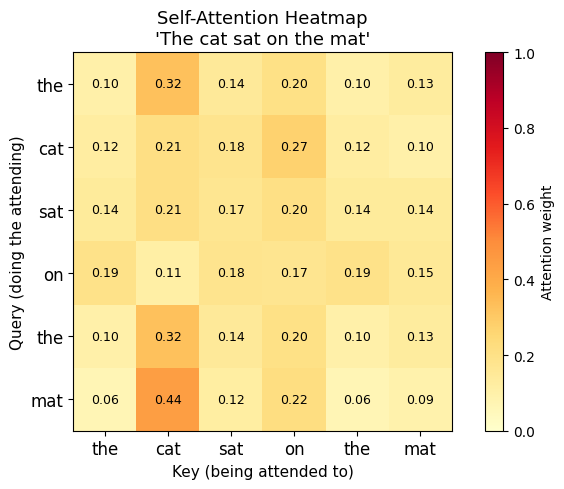

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(attn_weights, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, fontsize=12)
ax.set_yticklabels(tokens, fontsize=12)
ax.set_xlabel("Key (being attended to)", fontsize=11)
ax.set_ylabel("Query (doing the attending)", fontsize=11)
ax.set_title("Self-Attention Heatmap\n'The cat sat on the mat'", fontsize=13)

# Annotate each cell with the weight value
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="black" if attn_weights[i,j] < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

## 🟢 Step 9 — Before vs After: The Effect of Self-Attention 🔄

**Before self-attention:** Each token has a static embedding — it knows nothing about its neighbors.

**After self-attention:** Each token has a dynamic, context-aware vector — it has "talked" to every other token.

The word `cat` in *"The cat sat on the mat"* should have a different representation than `cat` in *"The cat chased the dog"* — because the surrounding context is different. Self-attention achieves this.

In [ ]:
print("=== 🔄 Before vs After Self-Attention ===")
print()
print(f"{'Token':8}  {'Before (raw embedding)':30}  {'After (context-aware)'}")
print("-" * 75)
for i, t in enumerate(tokens):
    before = str(X[i].round(2))
    after  = str(output[i].round(3))
    print(f"{t:8}  {before:30}  {after}")

print()
print("💡 Key insight: No token's output equals its original embedding anymore.")
print("   Every token has been enriched by the context of the full sentence.")

## 🟢 Step 10 — Output as a Weighted Equation 📐

Let's make the math concrete. Each output is literally a weighted sum:

```
Output('cat') = w₀×V_the + w₁×V_cat + w₂×V_sat + w₃×V_on + w₄×V_the + w₅×V_mat
```

This shows exactly which words contributed to each token's final representation.

In [ ]:
print("=== 📐 Output as Weighted Sum of Values ===")
print()

for i, token in enumerate(tokens):
    w = attn_weights[i]
    parts = [f"{w[j]:.2f}×V_{tokens[j]}" for j in range(len(tokens))]
    print(f"Output('{token}') = " + " + ".join(parts))
    print(f"               = {output[i].round(4)}")
    print()

## 🏁 Summary — What Just Happened?

| Step | What we did |
|------|-------------|
| 1 | Tokenized the sentence into words |
| 2 | Looked up a 4D embedding for each word |
| 3 | Projected embeddings into Q, K, V spaces via weight matrices |
| 4 | Computed raw scores: Q @ Kᵀ (dot product similarity) |
| 5 | Scaled by √dₖ, then applied softmax → attention weights |
| 6 | Computed output: weighted sum of V vectors |
| 7-10 | Interpreted and visualized the results |

---

## 🧠 The One Sentence to Remember

> **Self-attention lets every word ask "who should I pay attention to?" and blends the answers into a new, context-rich representation — dynamically, for every sentence.**

---

## 🔮 Try It Yourself!

Go back to **Step 1** and change the sentence. Try:
- `"The dog chased the cat"` — does `dog` attend to `chased`?
- `"She sat on the mat"` — how does `she` relate to `sat`?

New words are handled automatically — the vocabulary is built from your sentence, and each word gets a random embedding from the learned matrix.